# TAREA SEMANAL NUMERO 8: LA VENIDA DE LOS FILTROS DIGITALES

### CONSIGNAS
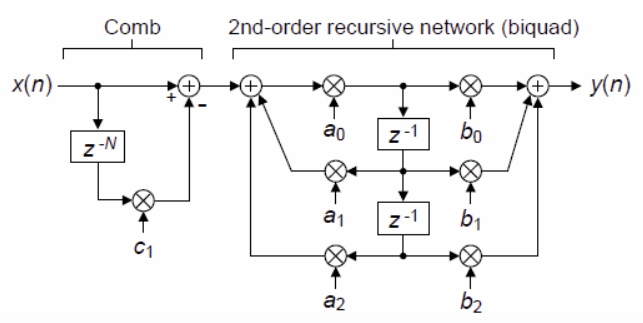
## 1. Verificación de transferencia

Comprobar que el esquema se corresponde con la siguiente transferencia:

$$
H(z) = (1 - c_1 z^{-N}) \cdot \frac{b_0 + b_1 z^{-1} + b_2 z^{-2}}{a_0 - a_1 z^{-1} - a_2 z^{-2}}
$$

---

## 2. Filtro de media móvil (Moving Average ó CIC: Cascaded Integrator Comb)

- Verificar la transferencia para:  
  - **a₀ = 1**  
  - **a₁ = 1**  
  - **b₀ = 1/N**  
  - **c₁ = 1**  
  - **N = 3, 4 y 5**

**Preguntas:**
- ¿Es un filtro **IIR** o **FIR**?  
- Discuta las **ventajas** que tendría esta implementación respecto al filtro FIR de media móvil.  
- ¿Podría implementar el siguiente sistema con esta topología?

$$
h(k) = (1, 1, 1, 1, 1, 1, 1)
$$

---

## 3. Filtro diferenciador (Differentiator)

- Obtener los valores de **aᵢ** y **bₖ** para que:

$$
y(n) = \frac{x(n) - x(n-2)}{2}
$$

- Evaluar el sistema con un **seno discreto en Python** y comprobar si la salida se aproxima a la **derivada**.

---

## 4. Filtro elimina continua (DC Blocker)

- Verifique la transferencia para:  
  - **a₀ = 1**  
  - **a₁ = β**  
  - **b₀ = 1**  
  - **b₁ = -1**  
  con **β = 0.9**

- Determine el valor de **β** para que la transferencia en  
  $$
  \Omega = 0.1 \pi
  $$  
  sea **3 dB menor** que la transferencia en  
  $$
  \Omega = \pi
  $$

---

## 5. Filtro Peine (Comb Filter)

- Verifique la transferencia para:  
  - **c₁ = -1**  
  - **N = 8**

- Proponga una **frecuencia de muestreo** (*f_sampling*) y halle las frecuencias donde se generan los **peaks** y los **nulls** en el espectro.

---

## Importante

Para todos los incisos:  
- Calcular y representar sus **singularidades en el plano z**.  
- Obtener la **respuesta de módulo y fase de H(z)**.  
- Dibujar su **diagrama en bloques**.  

Cuando no se indique, considerar los **coeficientes igual a cero**.

---

## Bonus 🎖️

- 🥉 Verificar en **Python** el punto 3) con la función `diff`.  
- 🥉 Utilizando solo el **biquad**, hallar los valores de los coeficientes para emular la respuesta analógica de un **pasa-todo de orden 1**. (Use alguno de los métodos de diseño vistos en clase).  
- 🥉 Completar el siguiente **cuestionario**.  


### Resolución del inciso 1

Para la resolución del primer punto se adopta la estrategia de **segmentar el diagrama de bloques** en **tres secciones**.  

Posteriormente, se **multiplican** estas entre sí, resultando en la **transferencia deseada**:

![image.png](images/TS8_1.PNG)
![image.png](images/TS8_2.PNG)

$$
H(z) = (1 - c_1 z^{-N}) \cdot \frac{b_0 + b_1 z^{-1} + b_2 z^{-2}}{a_0 - a_1 z^{-1} - a_2 z^{-2}}
$$

Se logra demostrar con éxito que la **transferencia proporcionada** y la **obtenida** son la **misma transferencia**.


Importante: Para todo el resto de casos el diagrama de bloques sera el mismo variando el valor de los coeficientes. 

### Resolución del inciso 2

Planteando el segundo problema, con los coeficientes impuestos se llega a:

$$
H(z) = (1 - 1 \cdot z^{-N}) \cdot \frac{\tfrac{1}{N} + b_1 z^{-1} + b_2 z^{-2}}{1 - 1 \cdot z^{-1} - a_2 z^{-2}}
$$

Para obtener un **filtro de media móvil** se requiere la siguiente transferencia:

$$
H(z) = \frac{1}{N} \cdot \frac{1 - z^{-N}}{1 - z^{-1}}
$$

Por lo tanto, se deben ajustar los coeficientes de la siguiente manera:

- **a₂ = 0**  
- **b₁ = 0**  
- **b₂ = 0**  
- y usar el valor de **N** correspondiente.

---

#### Transferencias para cada caso

1. Para **N = 3**:
   $$
   H(z) = \tfrac{1}{3} \cdot \frac{1 - z^{-3}}{1 - z^{-1}}
   $$

2. Para **N = 4**:
   $$
   H(z) = \tfrac{1}{4} \cdot \frac{1 - z^{-4}}{1 - z^{-1}}
   $$

3. Para **N = 5**:
   $$
   H(z) = \tfrac{1}{5} \cdot \frac{1 - z^{-5}}{1 - z^{-1}}
   $$

![image.png](images/CIC_1.png)
![image.png](images/CIC_3.png)

---

el sistema h(k) = (1, 1, 1, 1, 1, 1, 1) da como resultado el siguiente filtro digital:

   $$
   H(z) = z^{-6} + z^{-5} + z^{-4} + z^{-3} + z^{-2} + z^{-1} + 1
   $$
![image.png](images/CIC_2.png)
   
#### Conclusiones

- En todos los casos resultan **filtros IIR**.  
- La ventaja principal de esta implementación es que, al **aumentar N**, **no aumenta la cantidad de memoria** que el filtro utiliza.  
- En cambio, en una implementación **FIR**, cada vez que **N aumenta**, la cantidad de memoria necesaria **crece proporcionalmente**.



### Resolución del inciso 3

partiendo de la feinicion del filtro en tiempo, se llega a:

![image.png](images/diff.png)

para lograr esta transferencia con nuetra topologia se opta por:

- $c_1$ = 0 
- $b_1$ = 0 
- $b_2$ = 1 
- $a_0$ = 0.5 
- $a_1$ = 0 
- $a_2$ = 0 


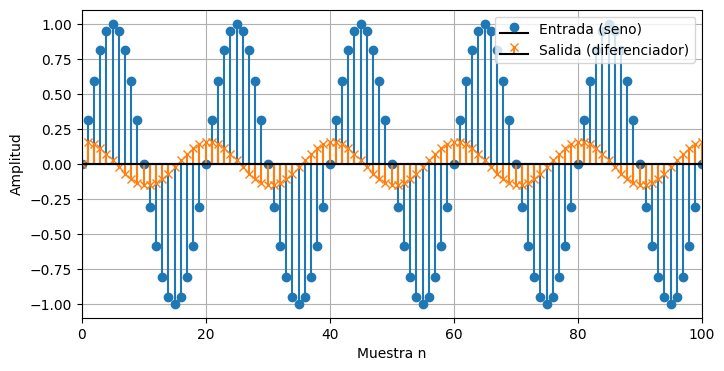

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Parámetros de la señal
fs = 1000          # Frecuencia de muestreo
f = 50             # Frecuencia del seno
N = 500            # Número de muestras

# Señal senoidal discreta
n = np.arange(N)
x = np.sin(2 * np.pi * f * n / fs)

# Diferenciador usando numpy.diff (o scipy.diff, que en realidad remite a lo mismo)
y = np.diff(x) / 2    # diff acorta en 1 la longitud
y = np.concatenate(([0], y))  # para que tenga misma longitud que x

# Graficar
plt.figure(figsize=(8,4))
plt.stem(n, x, linefmt='C0-', markerfmt='C0o', basefmt='k-', label='Entrada (seno)')
plt.stem(n, y, linefmt='C1-', markerfmt='C1x', basefmt='k-', label='Salida (diferenciador)')
plt.xlim([0, 100])
plt.xlabel('Muestra n')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()


### Resolución del inciso 4

Planteando el cuarto problema, con los coeficientes impuestos se llega a:

![image.png](images/DCB.png)

Para el segundo problema se procede: 
![image.png](images/TS8_4.png)
![image.png](images/TS8_5.png)
![image.png](images/TS8_7.png)

### Resolución del inciso 5

Planteando el quinto problema, con los coeficientes impuestos se llega a:

![image.png](images/peine1.png)
![image.png](images/peine2.png)
